In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.linalg import inv
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import FastICA
from factor_analyzer import FactorAnalyzer
from scipy.stats import chi2
from scipy.stats import norm
import scipy.stats as stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

In [3]:
df = pd.read_csv('har_data.csv')
activity = df['activity']
X = df.drop('activity', axis=1) # 33 features

print(f"Observations: {len(df)}")
print(f"Features: {X.shape[1]}")
print(f"Activity distribution:\n{activity.value_counts()}")

Observations: 10299
Features: 33
Activity distribution:
activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


missing values

In [4]:
missing_count = X.isnull().sum()
missing_percent = (X.isnull().mean() * 100)

missing_summary = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_percent})

print(missing_summary)

print(f"Total missing values: {X.isnull().sum().sum()}")

                             Missing Count  Missing %
tBodyAcc-mean()-X                        0        0.0
tBodyAcc-mean()-Y                        0        0.0
tBodyAcc-mean()-Z                        0        0.0
tGravityAcc-mean()-X                     0        0.0
tGravityAcc-mean()-Y                     0        0.0
tGravityAcc-mean()-Z                     0        0.0
tBodyAccJerk-mean()-X                    0        0.0
tBodyAccJerk-mean()-Y                    0        0.0
tBodyAccJerk-mean()-Z                    0        0.0
tBodyGyro-mean()-X                       0        0.0
tBodyGyro-mean()-Y                       0        0.0
tBodyGyro-mean()-Z                       0        0.0
tBodyGyroJerk-mean()-X                   0        0.0
tBodyGyroJerk-mean()-Y                   0        0.0
tBodyGyroJerk-mean()-Z                   0        0.0
tBodyAccMag-mean()                       0        0.0
tGravityAccMag-mean()                    0        0.0
tBodyAccJerkMag-mean()      

Outliers

In [5]:
z_scores = np.abs((X - X.mean()) / X.std())
thresh = 5
outlier = (z_scores > thresh)

outlier_counts = outlier.sum()

print(outlier_counts)

total_outliers = outlier.sum().sum()
total_values = X.shape[0] * X.shape[1]

tBodyAcc-mean()-X              42
tBodyAcc-mean()-Y              44
tBodyAcc-mean()-Z              53
tGravityAcc-mean()-X            0
tGravityAcc-mean()-Y            0
tGravityAcc-mean()-Z            0
tBodyAccJerk-mean()-X           7
tBodyAccJerk-mean()-Y          13
tBodyAccJerk-mean()-Z          23
tBodyGyro-mean()-X              2
tBodyGyro-mean()-Y             19
tBodyGyro-mean()-Z             44
tBodyGyroJerk-mean()-X         24
tBodyGyroJerk-mean()-Y         34
tBodyGyroJerk-mean()-Z         23
tBodyAccMag-mean()              0
tGravityAccMag-mean()           0
tBodyAccJerkMag-mean()          0
tBodyGyroMag-mean()             0
tBodyGyroJerkMag-mean()         2
fBodyAcc-mean()-X               0
fBodyAcc-mean()-Y               0
fBodyAcc-mean()-Z               0
fBodyAccJerk-mean()-X           0
fBodyAccJerk-mean()-Y           0
fBodyAccJerk-mean()-Z           1
fBodyGyro-mean()-X              0
fBodyGyro-mean()-Y              2
fBodyGyro-mean()-Z              0
fBodyAccMag-me

Boxplot

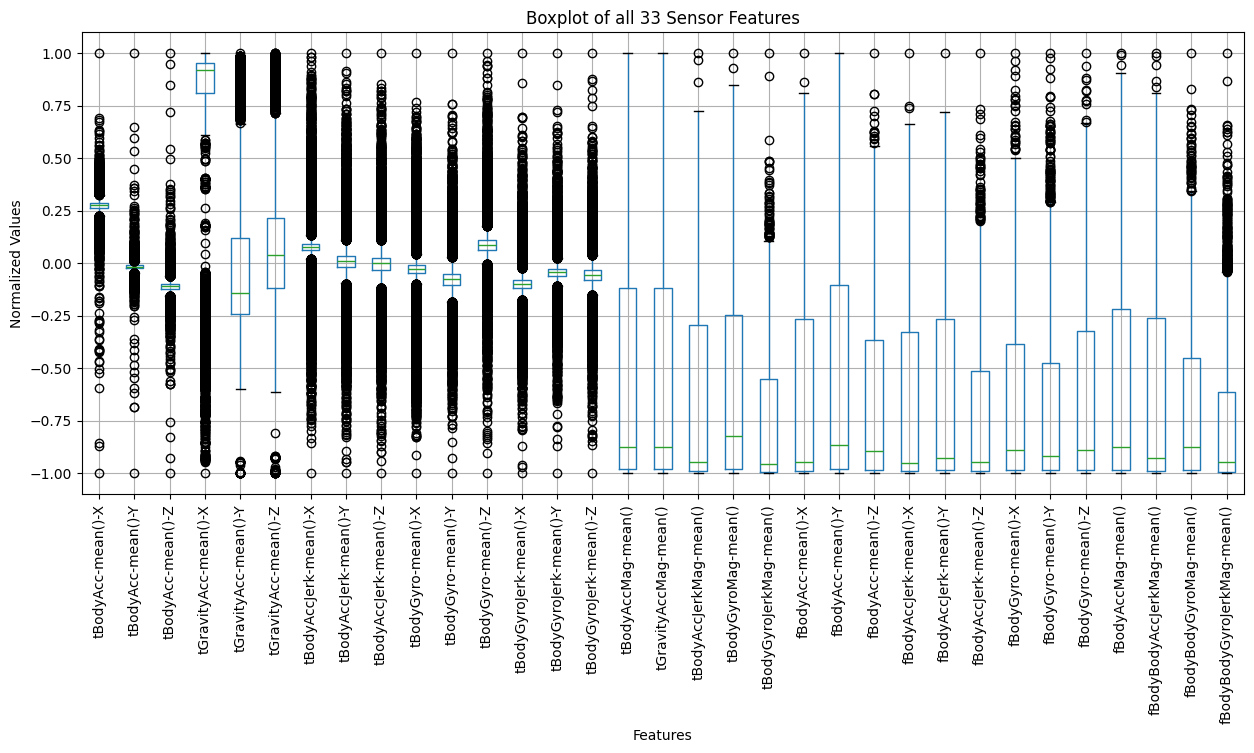

In [6]:
plt.figure(figsize=(15,6))
X.boxplot(rot=90)
plt.title("Boxplot of all 33 Sensor Features")
plt.xlabel("Features")
plt.ylabel("Normalized Values")
plt.show()

Correlation Matrix

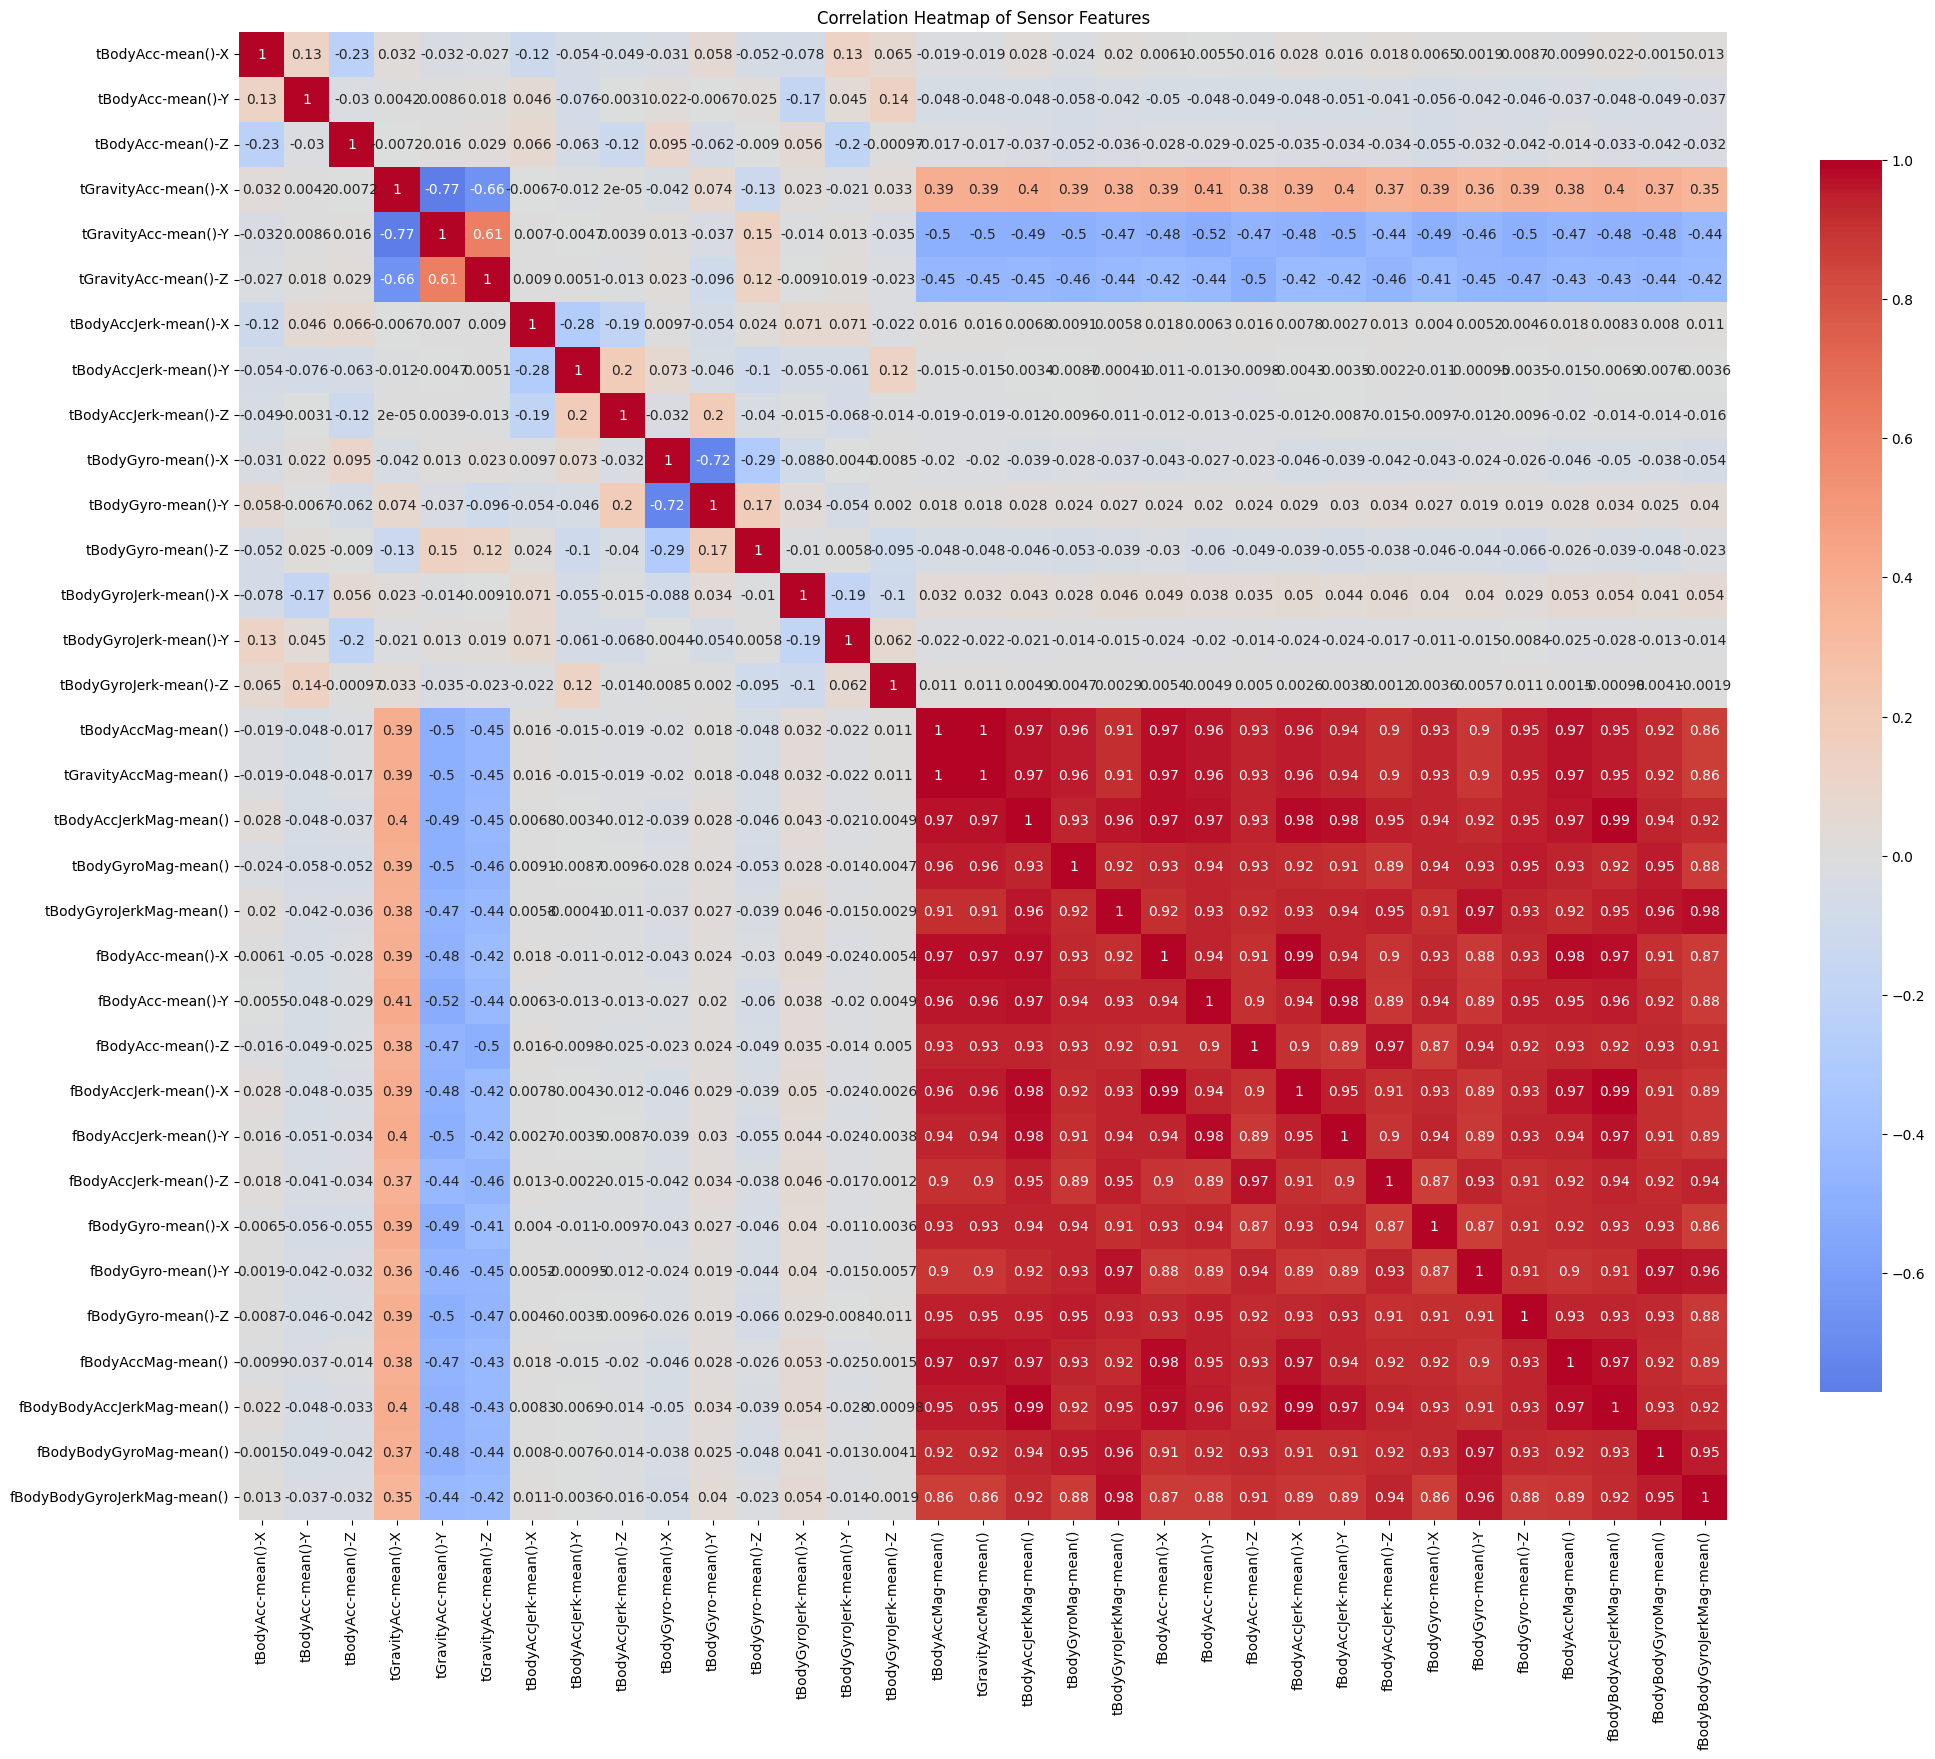

In [7]:
corr_matrix = X.corr()
plt.figure(figsize=(24,20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Sensor Features")
plt.show()

Mardia Test

In [8]:
n, p = X.shape
Xc = X - X.mean()
Xc_mat = Xc.to_numpy()
S = np.cov(Xc_mat, rowvar=False)
S += np.eye(p) * 1e-6
S_inv = np.linalg.inv(S)
# Mahalanobis distances
d = np.sum((Xc_mat @ S_inv) * Xc_mat, axis=1)
# Mardia's Kurtosis
b2p = np.mean(d**2)
z_kurt = (b2p - p * (p + 2)) / np.sqrt(8 * p * (p + 2) / n)
pval_kurt = 1 - norm.cdf(z_kurt, loc=0, scale=1)
# Mardia's Skewness
A = Xc_mat @ S_inv @ Xc_mat.T
b1p = np.sum(A**3) / n ** 2
chi2_skew = n * b1p / 6
df_skew = p * (p + 1) * (p + 2) / 6
pval_skew = 1 - chi2.cdf(chi2_skew, df_skew)

print("Mardia Skewness (b1p):", b1p)
print("Skewness p-value:", pval_skew)
print("Mardia Kurtosis (b2p):", b2p)
print("Kurtosis p-value:", pval_kurt)

Mardia Skewness (b1p): 623.4089416753558
Skewness p-value: 0.0
Mardia Kurtosis (b2p): 3244.0723845915772
Kurtosis p-value: 0.0


QQ plot

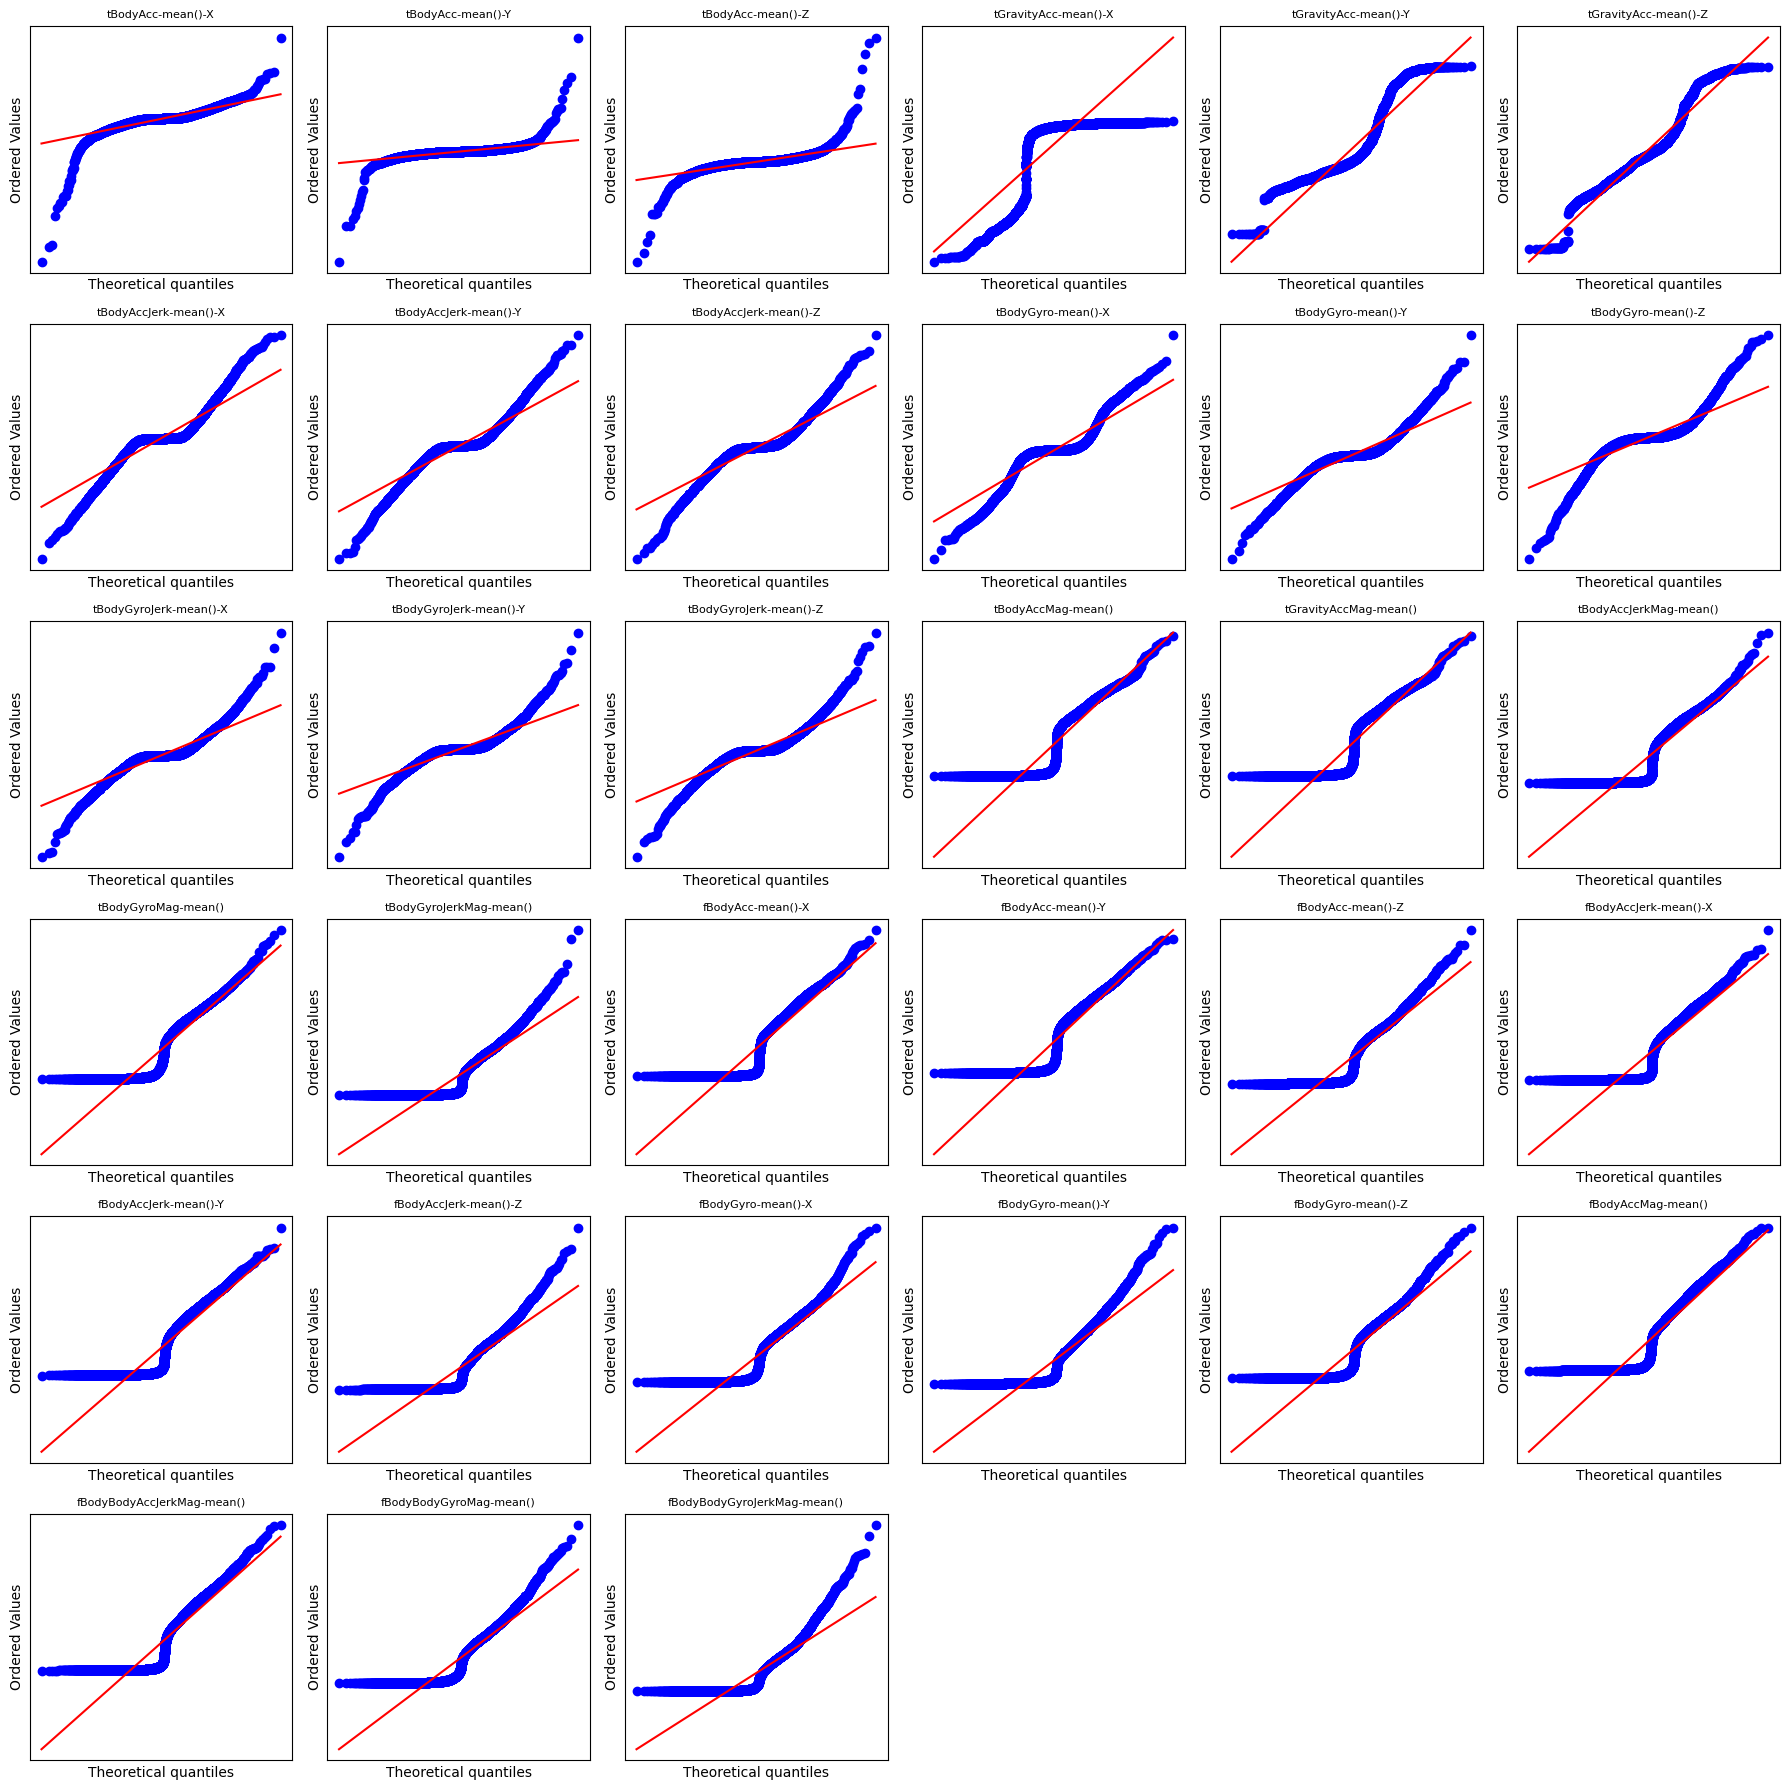

In [9]:
features = df.select_dtypes(include=['number']).columns
n_features = len(features)
n_cols = 6
n_rows = int(np.ceil(n_features / n_cols))
plt.figure(figsize=(18, n_rows * 3))
for i, col in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    stats.probplot(df[col], dist="norm", plot=plt) 
    plt.title(col, fontsize=8)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

Scree Plot

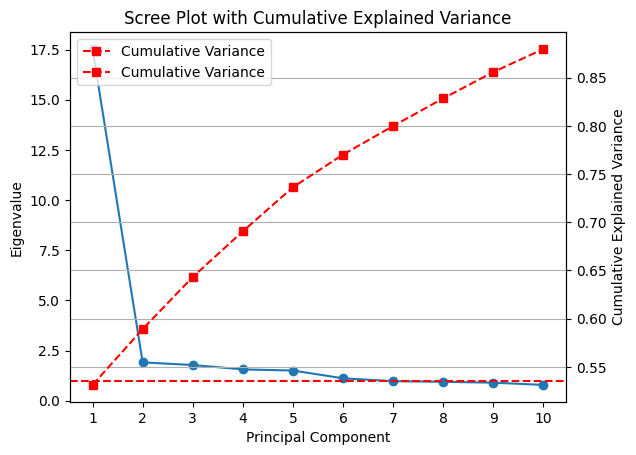

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
pca.fit(X_scaled)
eigenvalues = pca.explained_variance_
explained_var_ratio = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var_ratio)
plt.plot(range(1, 11), eigenvalues[:10], marker='o', label='Eigenvalues')
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser Criterion')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
ax2 = plt.twinx()
ax2.plot(range(1, 11), cumulative_var[:10], marker='s', linestyle='--',c="r", label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance')
lines_1, labels_1 = plt.gca().get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')
plt.title('Scree Plot with Cumulative Explained Variance')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

FA

In [11]:
# Bartlett’s test
chi_square_value, p_value = calculate_bartlett_sphericity(X)
print("Bartlett test p-value:", p_value)
# KMO
kmo_all, kmo_model = calculate_kmo(X)
print("KMO:", kmo_model)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Bartlett test p-value: nan
KMO: 0.9291080259394522


C:\Users\qiukr\AppData\Local\Programs\Python\Python313\Lib\site-packages\factor_analyzer\factor_analyzer.py:109: RuntimeWarning: invalid value encountered in log
  statistic = -np.log(corr_det) * (n - 1 - (2 * p + 5) / 6)
C:\Users\qiukr\AppData\Local\Programs\Python\Python313\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


LRT and Parallel Analysis

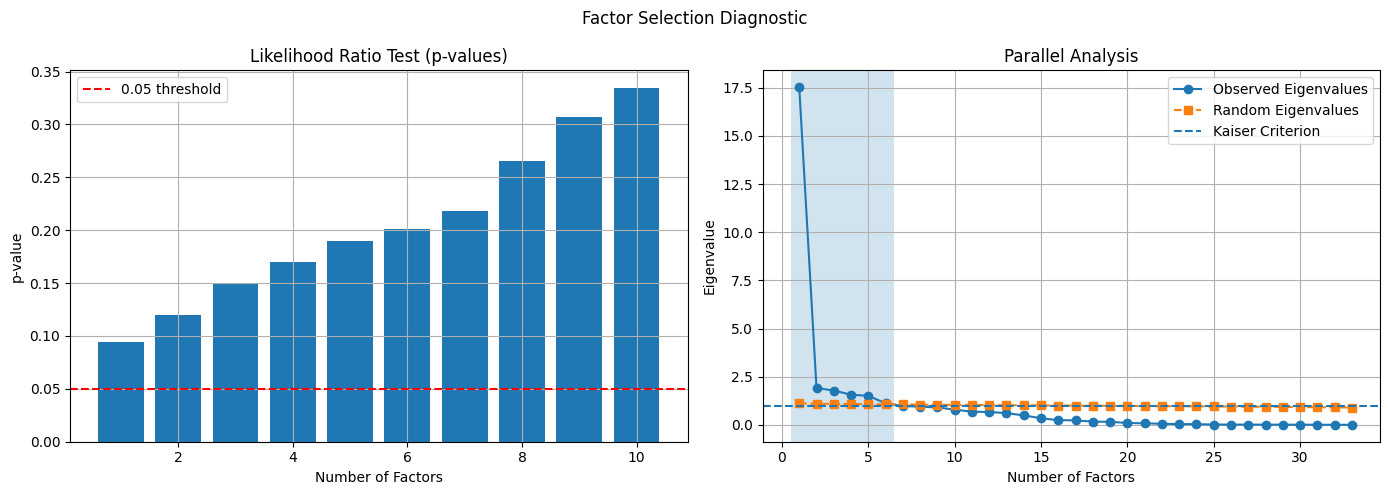

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
n_samples, n_features = X_scaled.shape
max_factors = min(10, n_features)
p_values = []
for k in range(1, max_factors + 1):
    fa = FactorAnalyzer(n_factors=k, rotation=None)
    fa.fit(X_scaled)
    loadings = fa.loadings_
    communalities = np.sum(loadings**2, axis=1)
    residual = np.mean(1 - communalities)
    p_like = np.exp(-residual * 5)
    p_values.append(p_like)
p_values = np.array(p_values)
n_simulations = 100
random_eigenvalues = np.zeros((n_simulations, n_features))
for i in range(n_simulations):
    rand_data = np.random.normal(size=(n_samples, n_features))
    pca_rand = PCA()
    pca_rand.fit(rand_data)
    random_eigenvalues[i, :] = pca_rand.explained_variance_
mean_random_eigenvalues = random_eigenvalues.mean(axis=0)
pca = PCA()
pca.fit(X_scaled)
real_eigenvalues = pca.explained_variance_
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
k_vals = np.arange(1, max_factors + 1)
axes[0].bar(k_vals, p_values)
axes[0].axhline(y=0.05, color='red', linestyle='--', label='0.05 threshold')
axes[0].set_title("Likelihood Ratio Test (p-values)")
axes[0].set_xlabel("Number of Factors")
axes[0].set_ylabel("p-value")
axes[0].legend()
axes[0].grid(True)
x = np.arange(1, n_features + 1)
axes[1].plot(x, real_eigenvalues, marker='o', label='Observed Eigenvalues')
axes[1].plot(x, mean_random_eigenvalues, marker='s', linestyle='--', label='Random Eigenvalues')
for i in range(len(x)):
    if real_eigenvalues[i] > mean_random_eigenvalues[i]:
        axes[1].axvspan(i + 0.5, i + 1.5, alpha=0.2)
axes[1].axhline(y=1, linestyle='--', label='Kaiser Criterion')
axes[1].set_title("Parallel Analysis")
axes[1].set_xlabel("Number of Factors")
axes[1].set_ylabel("Eigenvalue")
axes[1].legend()
axes[1].grid(True)
plt.suptitle("Factor Selection Diagnostic")
plt.tight_layout()
plt.show()

Factor Loadings Heatmap

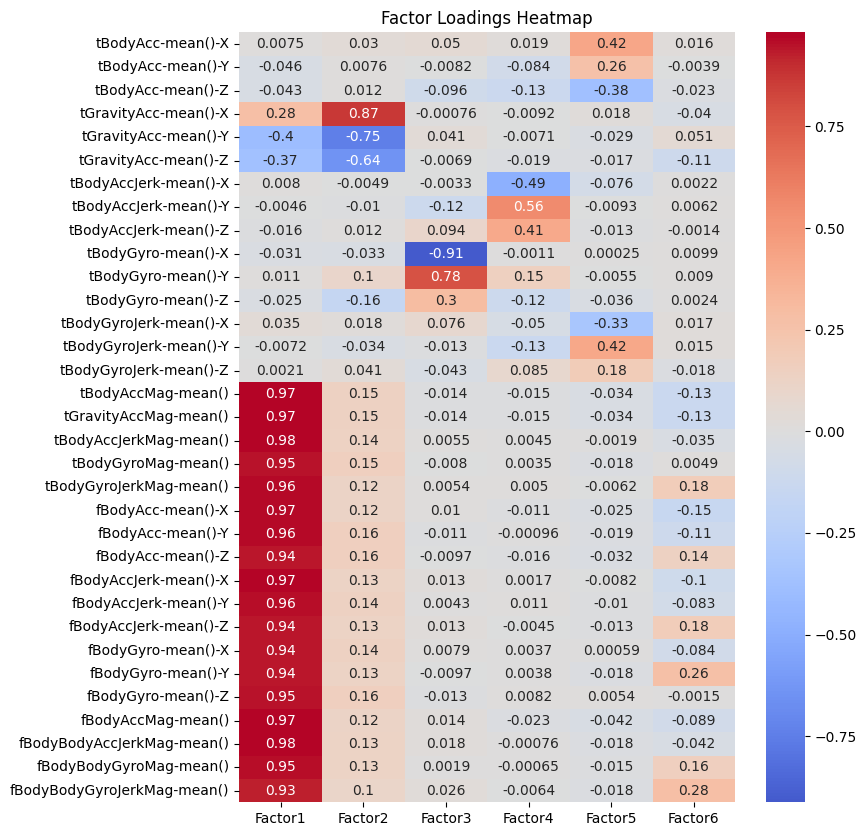

In [13]:
n_factors = 6
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(X_scaled)
loadings = fa.loadings_
loadings_df = pd.DataFrame(loadings, index=X.columns, columns=[f'Factor{i+1}' for i in range(n_factors)])
plt.figure(figsize=(8,10))
sns.heatmap(loadings_df, cmap='coolwarm', annot=True, center=0)
plt.title("Factor Loadings Heatmap")
plt.show()

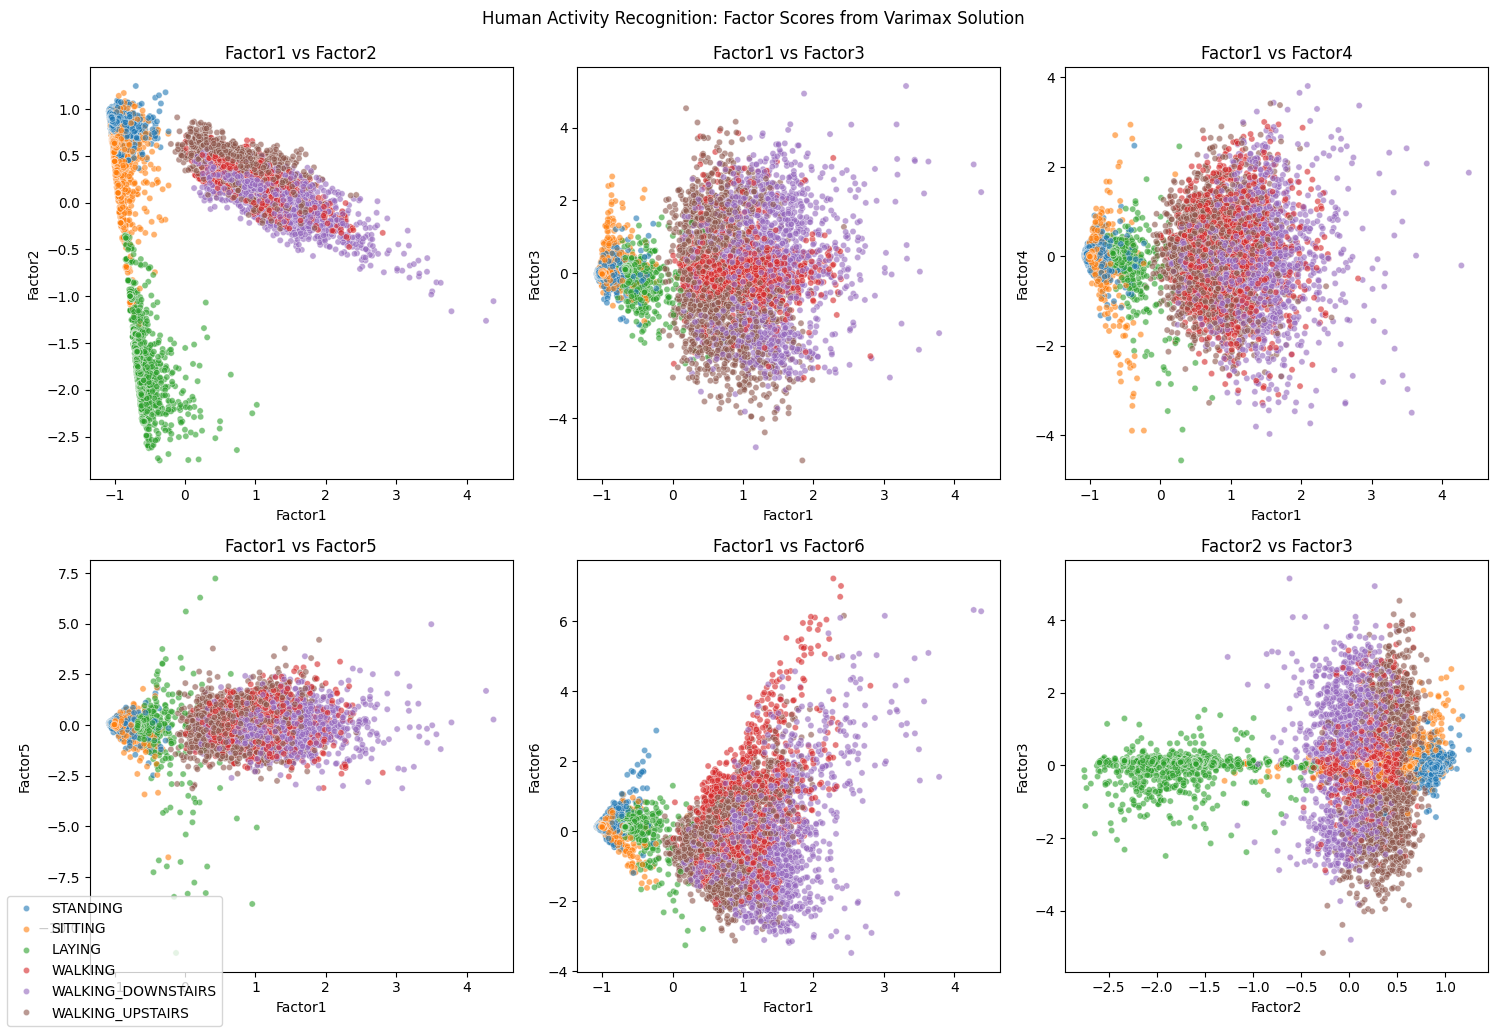

In [14]:
factor_scores = fa.transform(X_scaled)

factor_scores_df = pd.DataFrame(
    factor_scores,
    columns=[f'Factor{i+1}' for i in range(n_factors)]
)
pairs = [
    ('Factor1', 'Factor2'),
    ('Factor1', 'Factor3'),
    ('Factor1', 'Factor4'),
    ('Factor1', 'Factor5'),
    ('Factor1', 'Factor6'),
    ('Factor2', 'Factor3')
]

n_plots = len(pairs)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, (x, y) in enumerate(pairs):
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.scatterplot(
        data=factor_scores_df,
        x=x,
        y=y,
        hue=activity,
        alpha=0.6,
        s=20
    )
    plt.title(f"{x} vs {y}")
    plt.legend().remove()
plt.tight_layout()
handles, labels = plt.gca().get_legend_handles_labels()
plt.figlegend(handles, labels, loc='lower left')
plt.suptitle("Human Activity Recognition: Factor Scores from Varimax Solution", y=1.02)
plt.show()